In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv("stock_analys.csv")

In [3]:
df

,Date,Open,High,Low,Close,Volume
0,2026-01-05,100.00,100.34,99.06,100.00,1035672
1,2026-01-06,99.15,100.87,97.93,99.85,610835
2,2026-01-07,99.60,102.35,99.35,101.12,760093
3,2026-01-08,100.91,104.43,99.89,103.99,850786
4,2026-01-09,103.49,104.70,102.45,103.65,857047
...,...,...,...,...,...,...
95,2026-05-18,87.80,88.30,85.11,85.49,1078468
96,2026-05-19,85.69,86.89,85.45,86.03,930836
97,2026-05-20,85.57,87.85,84.48,86.52,694413
98,2026-05-21,86.60,87.14,86.50,86.61,821449


In [4]:
df.head()

,Date,Open,High,Low,Close,Volume
0,2026-01-05,100.00,100.34,99.06,100.00,1035672
1,2026-01-06,99.15,100.87,97.93,99.85,610835
2,2026-01-07,99.60,102.35,99.35,101.12,760093
3,2026-01-08,100.91,104.43,99.89,103.99,850786
4,2026-01-09,103.49,104.70,102.45,103.65,857047


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    100 non-null    object 
 1   Open    100 non-null    float64
 2   High    100 non-null    float64
 3   Low     100 non-null    float64
 4   Close   100 non-null    float64
 5   Volume  100 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 4.8+ KB


In [6]:
df.tail()

,Date,Open,High,Low,Close,Volume
95,2026-05-18,87.80,88.30,85.11,85.49,1078468
96,2026-05-19,85.69,86.89,85.45,86.03,930836
97,2026-05-20,85.57,87.85,84.48,86.52,694413
98,2026-05-21,86.60,87.14,86.50,86.61,821449
99,2026-05-22,86.64,87.81,85.68,86.34,718657


In [7]:
df["Date"]=pd.to_datetime(df["Date"])
df.dtypes

Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object

In [8]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [17]:
df["MA_20"]=df["Close"].rolling(20).mean()
df["MA_50"]=df["Close"].rolling(50).mean()

In [9]:
df["Daily_Return"]=(df["Close"]/df["Open"])*100

In [10]:
df

,Date,Open,High,Low,Close,Volume,Daily_Return
0,2026-01-05,100.00,100.34,99.06,100.00,1035672,100.000000
1,2026-01-06,99.15,100.87,97.93,99.85,610835,100.706001
2,2026-01-07,99.60,102.35,99.35,101.12,760093,101.526104
3,2026-01-08,100.91,104.43,99.89,103.99,850786,103.052225
4,2026-01-09,103.49,104.70,102.45,103.65,857047,100.154604
...,...,...,...,...,...,...,...
95,2026-05-18,87.80,88.30,85.11,85.49,1078468,97.369021
96,2026-05-19,85.69,86.89,85.45,86.03,930836,100.396779
97,2026-05-20,85.57,87.85,84.48,86.52,694413,101.110202
98,2026-05-21,86.60,87.14,86.50,86.61,821449,100.011547


In [18]:
mean_return=df["Daily_Return"].mean()
print("mean_return", mean_return)

variance_return=df["Daily_Return"].var() 
print("variance_return", variance_return)

standard_return=df["Daily_Return"].std() 
print("standard_return", standard_return)


mean_return 99.85771580089671
variance_return 4.62632629899549
standard_return 2.150889652910044


In [13]:
import matplotlib.pyplot as plt

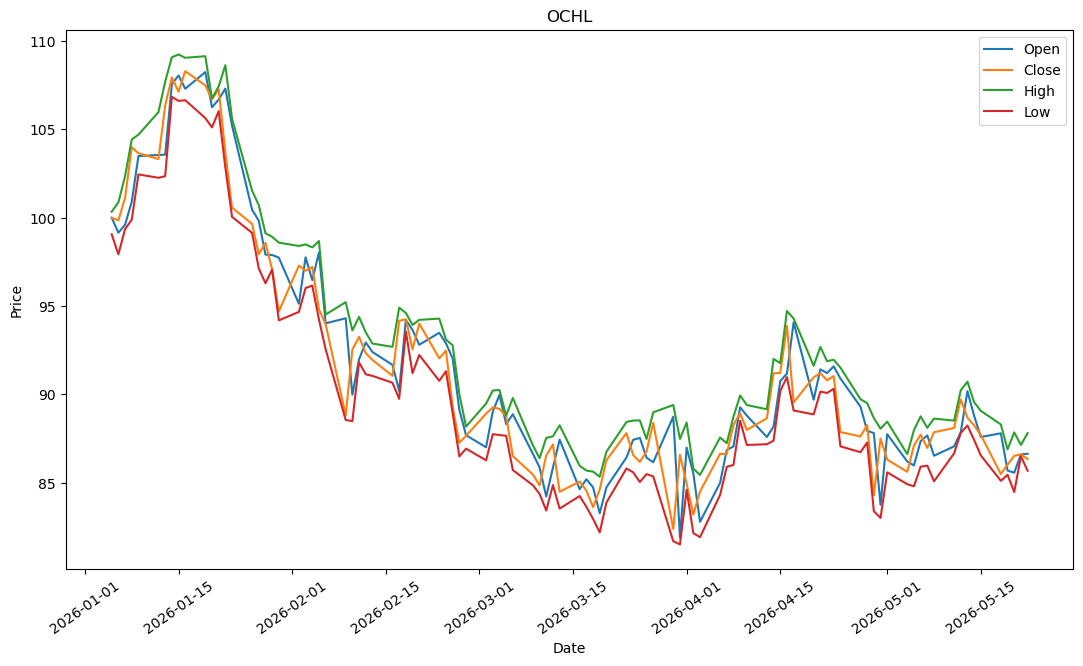

In [14]:
plt.figure(figsize=(13,7))
plt.plot(df["Date"],df["Open"],label="Open")
plt.plot(df["Date"],df["Close"],label="Close")
plt.plot(df["Date"],df["High"],label="High")
plt.plot(df["Date"],df["Low"],label="Low")
plt.title("OCHL")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=35)
plt.show()

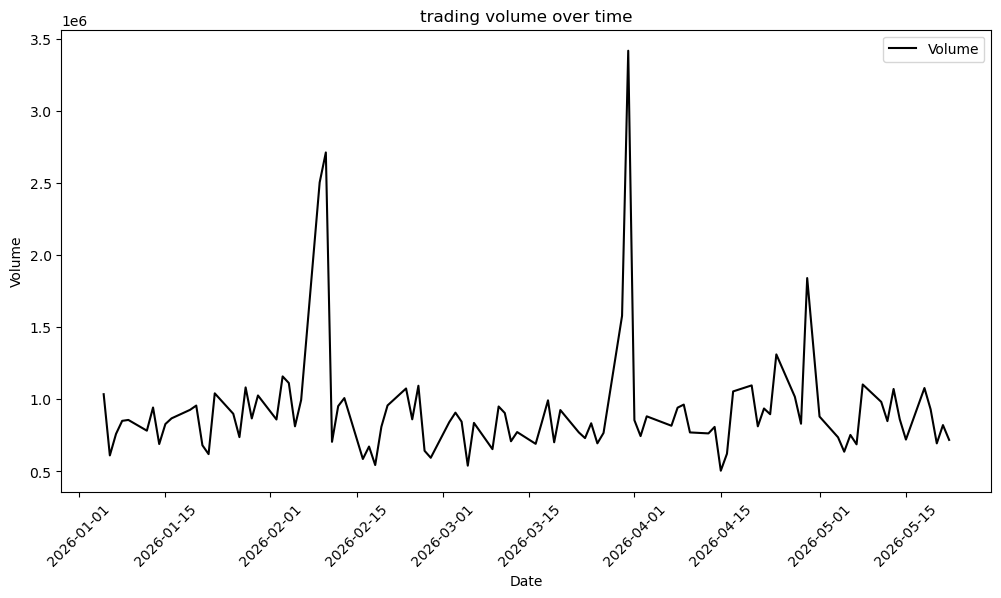

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Volume"], label="Volume", color="Black")
plt.title("trading volume over time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.xticks(rotation=45)
plt.show()

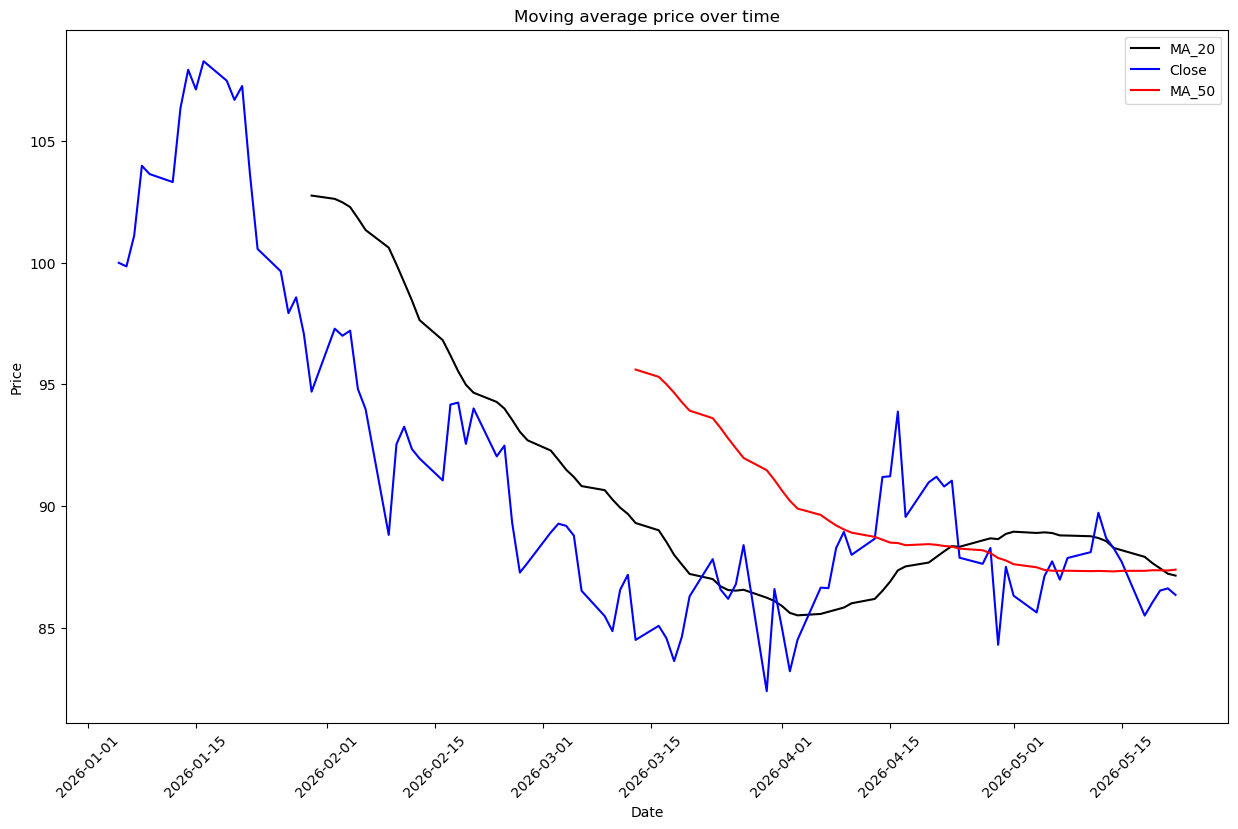

In [20]:
plt.figure(figsize=(15,9))
plt.plot(df["Date"],df["MA_20"], label="MA_20", color="Black")
plt.plot(df["Date"], df["Close"], label="Close", color="Blue")
plt.plot(df["Date"], df["MA_50"], label="MA_50", color="red")
plt.title("Moving average price over time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [21]:
import seaborn as sns

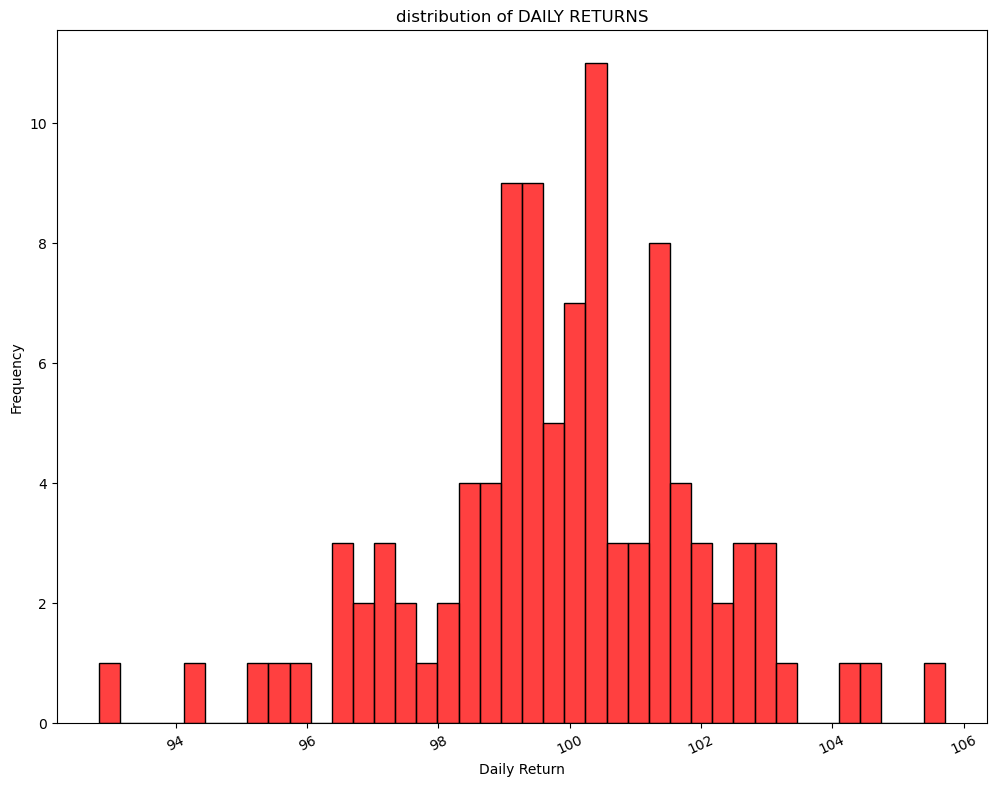

In [22]:
plt.figure(figsize=(12,9))
sns.histplot(df["Daily_Return"], bins=40,color="red")
plt.title("distribution of DAILY RETURNS")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.xticks(rotation=25)
plt.show()

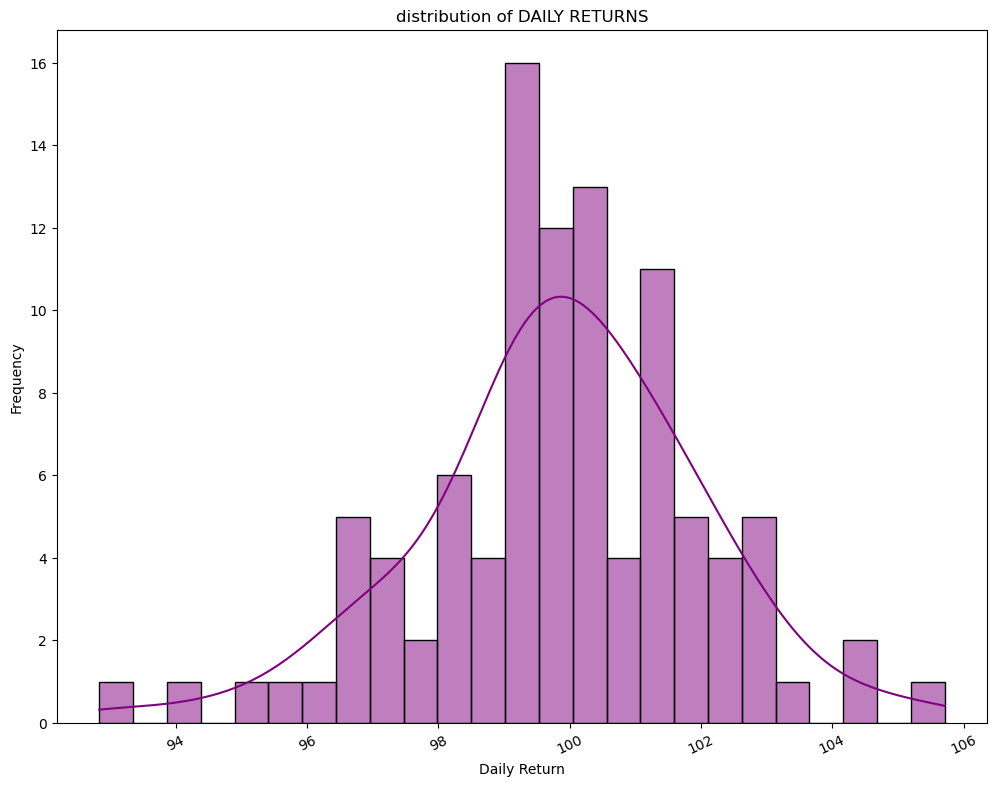

In [24]:
plt.figure(figsize=(12,9))
sns.histplot(df ["Daily_Return"], bins=25, kde=True, color="PURPLE")
plt.title("distribution of DAILY RETURNS")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.xticks(rotation=25)
plt.show()

In [26]:
avg_daily_return = df ['Daily_Return'].mean()
variance = df['Daily_Return'].var()
std_deviation = df ['Daily_Return'].std()
max_return = df ['Daily_Return'].max()
min_return = df ['Daily_Return'].min()

print("FINANCIAL SUMMARY")
print("*"*30)
print("AVERAGE DAILY RETURNS:", avg_daily_return)
print("VARIANCE:", variance)
print("STANDARD DEVIATION:", std_deviation)
print("MAXIMUM DAILY RETURN:", max_return)
print("MINIMUM DAILY RETURN:", min_return)

FINANCIAL SUMMARY
******************************
AVERAGE DAILY RETURNS: 99.85771580089671
VARIANCE: 4.62632629899549
STANDARD DEVIATION: 2.150889652910044
MAXIMUM DAILY RETURN: 105.7142857142857
MINIMUM DAILY RETURN: 92.83299526707235
